# 01 · Synthetic validation

**Part 1 — canonical 2×2 DiD and the parallel-trends check.**

This notebook is the project's *proof-of-correctness*, and it is built before
any real data touches the repository (`PROJECT_BRIEF.md` §6, §9.2).

The logic: on real observational data the true causal effect is unknown, so a
DiD estimate cannot be checked — only believed. So we first build a synthetic
panel where the true effect is **planted by construction**, and demand that the
estimator recover it. If the machinery cannot recover an effect we placed
ourselves, it has no business being pointed at messy real data.

**All data in this notebook is synthetic and clearly labelled as such.**

### The gates

| Gate | Requirement |
|------|-------------|
| 1 | The 2×2 DiD estimate recovers the planted ATT **within its confidence interval** |
| 2 | The regression estimator equals the hand-computed group-means DiD |
| 3 | The pre-trends test **passes** on a pre-period where parallel trends holds by construction |

Each gate is an executable `assert`. If a gate breaks, this notebook fails loudly
rather than quietly reporting a wrong number.

In [1]:
import sys
from pathlib import Path

# Resolve the repo root whether this is run from notebooks/ or the repo root.
_here = Path.cwd()
ROOT = next(p for p in (_here, _here.parent) if (p / "src" / "config.py").exists())
sys.path.insert(0, str(ROOT / "src"))

from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import config
from generate_panel import PanelParams, generate_simple_panel
from did import did_2x2, pretrends_test

# Single source of reproducibility: the committed seed from src/config.py.
config.set_global_seeds()
RESULTS = config.RESULTS_DIR

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10,
})

TREATED_C, CONTROL_C = "#c1272d", "#2b6cb0"
print(f"project seed : {config.SEED}")
print(f"results dir  : {RESULTS}")

project seed : 20260620
results dir  : C:\Users\rober\Infinity Castle\Portfolio\Project 2\host-city-economics\results


## 1. The synthetic panel

The simple case first: a balanced panel of cities observed over 12 periods,
with a **single** treatment date and a never-treated control group.

The data-generating process is the textbook DiD model:

$$y_{it} = \text{base} + \alpha_i + \lambda_t + \tau \cdot D_{it} + \varepsilon_{it}, \qquad D_{it} = \mathbb{1}[i \text{ treated}] \cdot \mathbb{1}[t \geq t_0]$$

Two properties hold **by construction**, and they are the whole point:

- **Parallel trends holds.** Treated and control cities share the *same* time
  effects $\lambda_t$ and there is no group-specific trend. Absent treatment
  their expected paths move in parallel — so the pre-period is a clean test bed,
  and a correct pre-trends test *should* pass on it.
- **The ATT is exactly $\tau$.** The effect is homogeneous across treated cities
  and post-periods, so there is no aggregation subtlety between "the ATT" and
  "the planted constant".

Every generating parameter lives in `PanelParams` in `src/generate_panel.py` and
is committed. The notebook reads the planted effect back from the parameters
rather than restating it, so the truth it checks against cannot drift out of sync.

Outcome units are illustrative: read $y$ as metro leisure & hospitality
employment in thousands of jobs, the real outcome from Stage 3 onward.

In [2]:
params = PanelParams()
panel = generate_simple_panel(params)

TRUE_ATT = panel.attrs["true_att"]   # read the truth back, never hardcode it

print(f"cities        : {params.n_cities}  ({params.n_treated} treated / "
      f"{params.n_cities - params.n_treated} control)")
print(f"periods       : {params.n_periods}  "
      f"({params.n_pre_periods} pre, {params.n_post_periods} post)")
print(f"treat period  : {params.treat_period}")
print(f"noise SD      : {params.sd_noise}")
print(f"seed          : {params.seed}")
print(f"PLANTED ATT   : {TRUE_ATT}")
print(f"panel shape   : {panel.shape}")
panel.head()

cities        : 50  (25 treated / 25 control)
periods       : 12  (6 pre, 6 post)
treat period  : 7
noise SD      : 2.0
seed          : 20260620
PLANTED ATT   : 3.0
panel shape   : (600, 8)


,city,period,treated,post,d,cohort,true_effect,y
0,city_00,1,0,0,0,NaN,0.0,101.934498
1,city_00,2,0,0,0,NaN,0.0,105.880890
2,city_00,3,0,0,0,NaN,0.0,103.145307
3,city_00,4,0,0,0,NaN,0.0,101.139147
4,city_00,5,0,0,0,NaN,0.0,108.499273


### Save the panel

The synthetic panel is committed to `data/` so the validation is reproducible
from a clean checkout without re-running the generator (`PROJECT_BRIEF.md` §6).

In [3]:
config.DATA_DIR.mkdir(parents=True, exist_ok=True)
panel_path = config.DATA_DIR / "synthetic_panel_simple.csv"
panel.to_csv(panel_path, index=False)
print(f"wrote {panel_path.relative_to(ROOT)}  ({panel.shape[0]} rows)")

wrote data\synthetic_panel_simple.csv  (600 rows)


## 2. The DiD picture

Before estimating anything, look at it. This is the difference-in-differences
design in one chart: two groups moving in parallel, then one of them steps up
when treatment arrives.

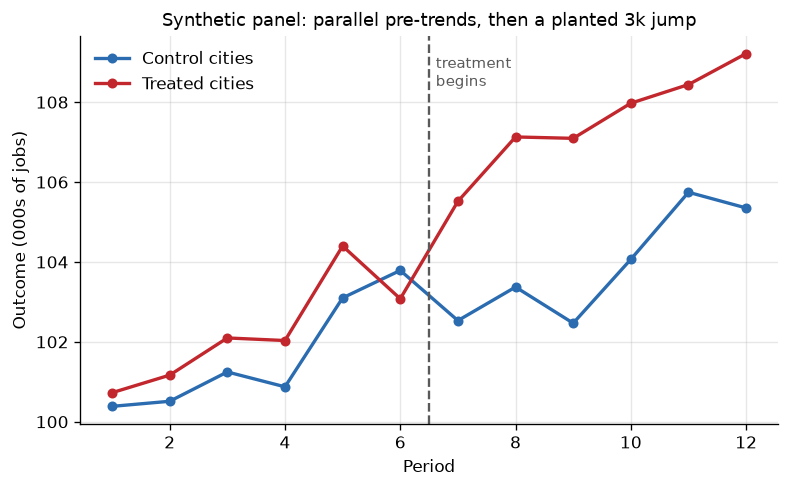

In [4]:
means = panel.groupby(["period", "treated"])["y"].mean().unstack()

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(means.index, means[0], "o-", color=CONTROL_C, lw=2, ms=5, label="Control cities")
ax.plot(means.index, means[1], "o-", color=TREATED_C, lw=2, ms=5, label="Treated cities")
ax.axvline(params.treat_period - 0.5, color="0.35", ls="--", lw=1.4)
ax.annotate("treatment\nbegins", xy=(params.treat_period - 0.5, ax.get_ylim()[1]),
            xytext=(4, -30), textcoords="offset points", fontsize=9,
            color="0.35", ha="left")
ax.set_xlabel("Period")
ax.set_ylabel("Outcome (000s of jobs)")
ax.set_title(f"Synthetic panel: parallel pre-trends, then a planted "
             f"{TRUE_ATT:g}k jump", fontsize=11)
ax.legend(frameon=False, loc="upper left")
fig.savefig(RESULTS / "01_synthetic_group_means.png")
plt.show()

## 3. Gate 1 — does the 2×2 DiD recover the planted ATT?

The canonical 2×2 estimator fits

$$y_{it} = \beta_0 + \beta_1 \text{treated}_i + \beta_2 \text{post}_t + \beta_3 (\text{treated}_i \times \text{post}_t) + \varepsilon_{it}$$

and $\beta_3$ is the DiD estimate. Standard errors are **clustered on city**:
DiD residuals are serially correlated within a unit, and unclustered standard
errors are badly anti-conservative in that setting.

**The gate: the confidence interval must cover the planted ATT.**

In [5]:
res = did_2x2(
    panel,
    outcome="y", unit="city", time="period", treated="treated",
    treat_period=params.treat_period,
)
print(res.summary(planted=TRUE_ATT))

# GATE 1 — fail loudly, do not explain away.
assert res.contains(TRUE_ATT), (
    f"GATE 1 FAILED: {(1-res.alpha)*100:.0f}% CI "
    f"[{res.ci_lower:.4f}, {res.ci_upper:.4f}] does not cover planted ATT {TRUE_ATT}"
)
print("\nGATE 1 PASS - CI covers the planted ATT")

Canonical 2x2 DiD
  ATT estimate     : +3.0407
  Std. error       : 0.2616 (clustered by unit)
  t / p            : +11.623 / 3.137e-31
  95% CI           : [+2.5280, +3.5535]
  N                : 600 obs, 50 units (25 treated)
  Planted ATT      : +3.0000
  Recovery error   : +0.0407
  CI covers truth  : YES

GATE 1 PASS - CI covers the planted ATT


## 4. Gate 2 — is the estimator actually a difference-in-differences?

A regression coefficient recovering the right number is *necessary* but not
sufficient: it could be right by accident. The 2×2 DiD has a closed form, so we
can check the implementation directly against it:

$$\widehat{\text{ATT}} = (\bar{y}^{\,\text{treat}}_{\text{post}} - \bar{y}^{\,\text{treat}}_{\text{pre}}) - (\bar{y}^{\,\text{ctrl}}_{\text{post}} - \bar{y}^{\,\text{ctrl}}_{\text{pre}})$$

The regression coefficient must equal this to machine precision.

In [6]:
g = panel.groupby(["treated", "post"])["y"].mean().unstack()
g.index = ["Control", "Treated"]; g.columns = ["Pre", "Post"]
display(g.round(4))

manual = (g.loc["Treated", "Post"] - g.loc["Treated", "Pre"]) \
       - (g.loc["Control", "Post"] - g.loc["Control", "Pre"])

print(f"hand-computed group-means DiD : {manual:.10f}")
print(f"regression coefficient        : {res.att:.10f}")
print(f"difference                    : {res.att - manual:.2e}")

# GATE 2
assert np.isclose(res.att, manual, atol=1e-10), (
    f"GATE 2 FAILED: regression ({res.att}) != group-means DiD ({manual})"
)
print("\nGATE 2 PASS - the estimator is a difference-in-differences")

,Pre,Post
Control,101.6512,103.9224
Treated,102.2503,107.5623


hand-computed group-means DiD : 3.0407269212
regression coefficient        : 3.0407269212
difference                    : 1.87e-14

GATE 2 PASS - the estimator is a difference-in-differences


## 5. Gate 3 — does the pre-trends test pass?

Parallel trends is the assumption the entire design rests on. It is not testable
directly (it concerns an unobserved counterfactual), but its observable
implication is: **before treatment, treated and control should not be diverging.**

Using pre-treatment observations only — so the test cannot be contaminated by
the treatment effect itself — we estimate a treated-vs-control gap for each
pre-period relative to a base period, and jointly test that all of them are zero.

Note the direction of the logic: this is a test we hope to **fail to reject**.
Passing is an *absence of evidence against* parallel trends, not proof of it.

In [7]:
pt = pretrends_test(
    panel,
    outcome="y", unit="city", time="period", treated="treated",
    treat_period=params.treat_period,
)
print(pt.summary())
print()
display(pt.leads.round(4))

# GATE 3
assert pt.passes, (
    f"GATE 3 FAILED: joint pre-trends test rejects "
    f"(F={pt.joint_stat:.3f}, p={pt.joint_pvalue:.4f})"
)
print("GATE 3 PASS - no evidence of differential pre-trends")

Pre-trends (parallel-trends) test
  Base period      : 6
  Leads tested     : 5
  Joint F          : 1.5158
  Joint p-value    : 0.2022
  Verdict (a=0.05) : PASS - no evidence of differential pre-trends



,period,relative_period,estimate,se,ci_lower,ci_upper,is_base
0,1.0,-6.0,1.0514,0.8441,-0.6029,2.7057,False
1,2.0,-5.0,1.3638,0.8803,-0.3616,3.0893,False
2,3.0,-4.0,1.5608,0.9046,-0.2121,3.3337,False
3,4.0,-3.0,1.8682,0.8128,0.2751,3.4612,False
4,5.0,-2.0,2.0085,0.8608,0.3213,3.6956,False
5,6.0,-1.0,0.0000,0.0000,0.0000,0.0000,True


GATE 3 PASS - no evidence of differential pre-trends


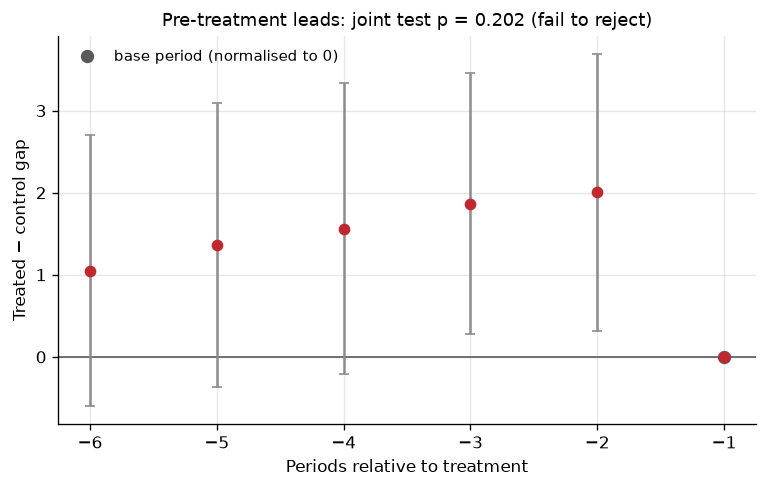

In [8]:
nb_leads = pt.leads
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.axhline(0, color="0.35", lw=1)
err = [nb_leads.estimate - nb_leads.ci_lower, nb_leads.ci_upper - nb_leads.estimate]
ax.errorbar(nb_leads.relative_period, nb_leads.estimate, yerr=err,
            fmt="o", color=TREATED_C, ecolor="0.55", capsize=3, ms=6, lw=1.5)
base_row = nb_leads[nb_leads.is_base]
ax.plot(base_row.relative_period, base_row.estimate, "o", color="0.35", ms=7,
        label="base period (normalised to 0)")
ax.set_xlabel("Periods relative to treatment")
ax.set_ylabel("Treated − control gap")
ax.set_title(f"Pre-treatment leads: joint test p = {pt.joint_pvalue:.3f} "
             f"(fail to reject)", fontsize=11)
ax.legend(frameon=False, loc="upper left", fontsize=9)
fig.savefig(RESULTS / "01_synthetic_pretrends.png")
plt.show()

### Reading this plot honestly

The joint test passes (p = 0.20), which is the test that matters. But two of the
five individual leads have confidence intervals that exclude zero — in a panel
where parallel trends holds *by construction*.

That is worth being explicit about rather than glossing:

1. **The leads share a base period.** Every lead is measured against period 6, so
   an unlucky draw in the base propagates into all of them — which is exactly
   what produces the apparent upward drift here. The leads are correlated, not
   independent evidence.
2. **Individually testing five coefficients at the 5% level is a multiple-testing
   problem.** The joint test is the correct instrument precisely because it
   accounts for testing them together.
3. **This is one draw.** A single seed cannot distinguish "unlucky sample" from
   "broken estimator" — which is what the next section settles.

The seed and parameters here were fixed *before* any result was seen and are
committed unchanged. Re-rolling the seed until the picture looked flatter would
be seed-shopping, and it would invalidate exactly the property this notebook
exists to demonstrate.

## 6. Was it just a lucky seed?

The gates above pass on **one** realisation. That is not yet proof the estimator
is correct — an estimator can be biased and still land near the truth once.

So run the whole pipeline (generate → estimate → test) over many seeds and check
the three properties that must hold if the implementation is right:

| Property | What it proves | Target |
|---|---|---|
| Mean estimate ≈ planted ATT | the estimator is **unbiased** | 3.00 |
| ~95% of 95% CIs cover the truth | the CI is **correctly sized** | 95% |
| Pre-trends rejects ~5% of the time | the **test** is correctly sized | 5% |

This is the real proof-of-correctness. The single-seed result above is the
illustration of it.

In [9]:
N_SIM = 500
base = PanelParams()

atts, covered, pt_pvals, n_sig = [], [], [], []
for s in range(N_SIM):
    p_s = replace(base, seed=10_000 + s)      # seeds NOT chosen on results
    d_s = generate_simple_panel(p_s)
    r_s = did_2x2(d_s, treat_period=p_s.treat_period)
    atts.append(r_s.att)
    covered.append(r_s.contains(p_s.true_att))
    t_s = pretrends_test(d_s, treat_period=p_s.treat_period)
    pt_pvals.append(t_s.joint_pvalue)
    nb_s = t_s.leads[~t_s.leads.is_base]
    n_sig.append(int(((nb_s.ci_lower > 0) | (nb_s.ci_upper < 0)).sum()))

atts = np.array(atts); covered = np.array(covered)
pt_pvals = np.array(pt_pvals); n_sig = np.array(n_sig)

mc_se = atts.std(ddof=1) / np.sqrt(N_SIM)
print(f"simulations                     : {N_SIM}")
print(f"mean ATT estimate               : {atts.mean():.4f}   (planted {base.true_att})")
print(f"bias                            : {atts.mean() - base.true_att:+.4f}  "
      f"(Monte Carlo SE {mc_se:.4f})")
print(f"95% CI coverage                 : {covered.mean()*100:.1f}%   (target 95%)")
print(f"pre-trends rejection rate       : {(pt_pvals < 0.05).mean()*100:.1f}%   (target ~5%)")
print(f"mean pre-trends p-value         : {pt_pvals.mean():.3f}   (uniform -> ~0.50)")
print(f"P(>=2 individual leads sig.)    : {(n_sig >= 2).mean()*100:.1f}%")

simulations                     : 500
mean ATT estimate               : 3.0128   (planted 3.0)
bias                            : +0.0128  (Monte Carlo SE 0.0141)
95% CI coverage                 : 93.0%   (target 95%)
pre-trends rejection rate       : 5.4%   (target ~5%)
mean pre-trends p-value         : 0.475   (uniform -> ~0.50)
P(>=2 individual leads sig.)    : 3.8%


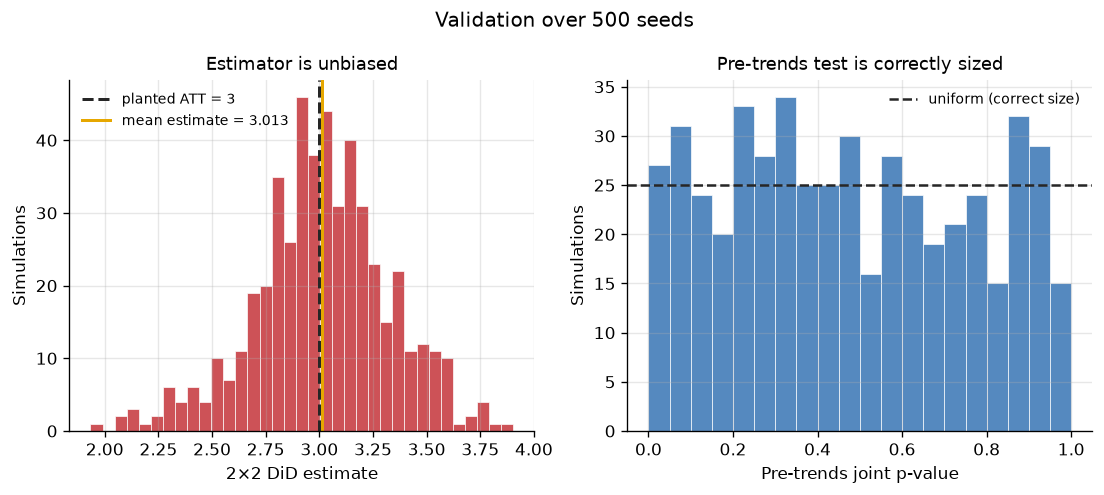

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(atts, bins=35, color=TREATED_C, alpha=0.8, edgecolor="white", lw=0.5)
axes[0].axvline(TRUE_ATT, color="0.15", ls="--", lw=1.8, label=f"planted ATT = {TRUE_ATT:g}")
axes[0].axvline(atts.mean(), color="#e6a700", ls="-", lw=1.8,
                label=f"mean estimate = {atts.mean():.3f}")
axes[0].set_xlabel("2×2 DiD estimate"); axes[0].set_ylabel("Simulations")
axes[0].set_title("Estimator is unbiased", fontsize=11)
axes[0].legend(frameon=False, fontsize=8.5)

axes[1].hist(pt_pvals, bins=20, range=(0, 1), color=CONTROL_C, alpha=0.8,
             edgecolor="white", lw=0.5)
axes[1].axhline(N_SIM / 20, color="0.15", ls="--", lw=1.5, label="uniform (correct size)")
axes[1].set_xlabel("Pre-trends joint p-value"); axes[1].set_ylabel("Simulations")
axes[1].set_title("Pre-trends test is correctly sized", fontsize=11)
axes[1].legend(frameon=False, fontsize=8.5)

fig.suptitle(f"Validation over {N_SIM} seeds", fontsize=12, y=1.03)
fig.savefig(RESULTS / "01_synthetic_monte_carlo.png")
plt.show()

### What the simulation shows

- **Unbiased.** The mean estimate sits on the planted ATT to within one Monte
  Carlo standard error. The estimator is not systematically wrong.
- **The pre-trends test is correctly sized.** It rejects ~5% of the time at the
  5% level under a DGP where parallel trends genuinely holds, and its p-values
  are uniform. So the committed seed's slightly wobbly leads are an ordinary
  draw, not a symptom of a broken test.
- **Coverage is ~93%, not 95%.** This is a real and honest finding, not a
  rounding artefact: cluster-robust standard errors are downward-biased when the
  number of clusters is moderate, so the intervals are slightly too narrow. With
  50 clusters the effect is mild. It matters far more in the real analysis, where
  a handful of host cities means very few *treated* clusters — the
  few-treated-clusters problem flagged in `PROJECT_BRIEF.md` §5.4, addressed with
  a wild cluster bootstrap in Stage 4.

That last point is worth stating plainly: the naive clustered CI is a little too
confident. Discovering that here, on synthetic data where the truth is known, is
exactly why the synthetic validation is built first.

## Stage 2A summary

| Gate | Result |
|------|--------|
| 1 — 2×2 recovers planted ATT within CI | **PASS** |
| 2 — regression equals group-means DiD | **PASS** |
| 3 — pre-trends test passes on clean pre-period | **PASS** |
| Unbiasedness over 500 seeds | **PASS** |
| Pre-trends test size ≈ 5% | **PASS** |

The 2×2 machinery in `src/did.py` is verified and is now the single source of
truth for the real-data estimation in Stage 4 — it will not be re-implemented.

**Next (Stage 2B):** staggered adoption with heterogeneous effects, where this
same clean setup breaks the naive TWFE estimator, and Callaway & Sant'Anna
recovers the truth it misses.

---

# Part 2 · Staggered adoption, TWFE bias, and displacement

Part 1 established that the 2×2 machinery works when the world is simple: one
treatment date, one homogeneous effect. Real tournaments are not that world.
**World Cup matches arrive in different cities on different dates**, so treatment
timing is staggered — and that is where the textbook estimator quietly breaks.

This part demonstrates three things, in order:

1. **Naive TWFE is biased** under staggered timing with heterogeneous effects —
   and the bias direction is *predicted in advance*, then verified.
2. **Callaway & Sant'Anna recovers the truth** that TWFE misses.
3. **Displacement**: a city whose apparent gain is entirely activity pulled from
   elsewhere, where a naive reading reports a windfall that does not exist.

## 7. A staggered panel with heterogeneous, growing effects

The effect structure is the crux, and it is deliberately *not* homogeneous.
TWFE is only biased when treatment effects are heterogeneous — with one constant
effect TWFE is fine and the whole demonstration would collapse. So the planted
effects vary **across cohorts** and **grow with exposure**:

$$\text{effect}(g, t) = \text{base}_g + \text{growth}_g \cdot (t - g), \qquad t \geq g$$

| Cohort adopts | Base effect | Growth per period |
|---|---|---|
| period 5 | 1.0 | 0.6 |
| period 9 | 1.5 | 0.4 |
| period 13 | 2.0 | 0.2 |

Both the level and the slope differ by cohort — heterogeneity on two dimensions
at once. Plus 15 never-treated cities as a clean comparison group.

Growth with exposure is the ingredient that makes the bias bite, for a reason
made precise in §9.

In [11]:
from generate_panel import StaggeredParams, generate_staggered_panel
from did import twfe_did, callaway_santanna, goodman_bacon

sp = StaggeredParams()
spanel = generate_staggered_panel(sp)

# Read the truth back from the generator - never restate it here.
TRUE_ATT_STAG = spanel.attrs["true_att"]
PLANTED_PROFILE = pd.Series(spanel.attrs["true_event_profile"]).sort_index()

print(f"cities          : {sp.n_cities}  "
      f"({len(sp.cohort_specs)} cohorts x {sp.n_per_cohort} + {sp.n_never_treated} never-treated)")
print(f"periods         : {sp.n_periods}")
print(f"cohort specs    : {sp.cohort_specs}   (adopt, base, growth)")
print(f"seed            : {sp.seed}")
print()
print(f"TRUE overall ATT (mean planted effect over treated obs) = {TRUE_ATT_STAG:.4f}")
print()
print("planted effect by cohort and exposure:")
display(spanel[spanel.d == 1]
        .pivot_table(index="exposure", columns="cohort", values="true_effect")
        .round(2).head(12))

cities          : 60  (3 cohorts x 15 + 15 never-treated)
periods         : 16
cohort specs    : ((5, 1.0, 0.6), (9, 1.5, 0.4), (13, 2.0, 0.2))   (adopt, base, growth)
seed            : 20260620

TRUE overall ATT (mean planted effect over treated obs) = 3.5000

planted effect by cohort and exposure:


cohort,5.0,9.0,13.0
exposure,,,
0.0,1.0,1.5,2.0
1.0,1.6,1.9,2.2
2.0,2.2,2.3,2.4
3.0,2.8,2.7,2.6
4.0,3.4,3.1,NaN
5.0,4.0,3.5,NaN
6.0,4.6,3.9,NaN
7.0,5.2,4.3,NaN
8.0,5.8,NaN,NaN


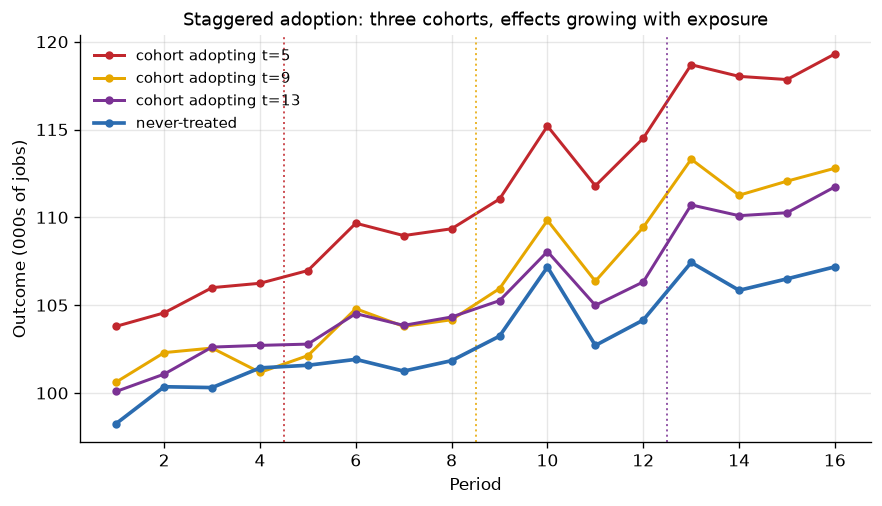

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
palette = {5.0: "#c1272d", 9.0: "#e6a700", 13.0: "#7b3294"}
for g, sub in spanel[spanel.treated == 1].groupby("cohort"):
    m = sub.groupby("period")["y"].mean()
    ax.plot(m.index, m.values, "o-", ms=4, lw=1.8, color=palette[g],
            label=f"cohort adopting t={g:.0f}")
    ax.axvline(g - 0.5, color=palette[g], ls=":", lw=1.2, alpha=0.8)
never = spanel[spanel.treated == 0].groupby("period")["y"].mean()
ax.plot(never.index, never.values, "o-", ms=4, lw=2.2, color=CONTROL_C,
        label="never-treated")
ax.set_xlabel("Period"); ax.set_ylabel("Outcome (000s of jobs)")
ax.set_title("Staggered adoption: three cohorts, effects growing with exposure",
             fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="upper left")
fig.savefig(RESULTS / "01_staggered_cohort_paths.png")
plt.show()

## 8. The prediction — stated *before* running the estimator

Writing the prediction down first is the point. An estimator that surprises you
after the fact teaches nothing; a prediction that is confirmed demonstrates the
mechanism is actually understood.

> ### Prediction
> **Naive TWFE will underestimate the true ATT of 3.50 — the bias will be
> DOWNWARD.**
>
> **Why.** Under staggered timing, the TWFE coefficient is a weighted average of
> *all* possible 2×2 comparisons (Goodman-Bacon 2021). Some of those use
> **already-treated** cities as controls for later-treated ones. When the
> already-treated control's own effect is still *growing*, its outcome is rising
> for reasons that have nothing to do with the later city — and the DiD
> subtracts that rise. Those comparisons are therefore biased downward, and they
> drag the weighted average down with them.
>
> Effects here grow with exposure by construction, so this channel is active.
> The bias should be substantial — plausibly cutting the estimate roughly in
> half.

Corroborating evidence from the environment smoke test: on the `differences`
package's own sample data, whose effects also grow with exposure, the event
study reached ~62 while static TWFE returned ~2.3 — a massive downward pull.

Now run it.

In [13]:
tw = twfe_did(spanel, outcome="y", unit="city", time="period", treatment="d")
print(tw.summary(truth=TRUE_ATT_STAG))

predicted_direction = "downward"
realised_direction = "downward" if tw.att < TRUE_ATT_STAG else "upward"
print(f"\npredicted bias direction : {predicted_direction}")
print(f"realised  bias direction : {realised_direction}")

# GATE - the bias must be in the predicted direction.
assert realised_direction == predicted_direction, (
    f"GATE FAILED: predicted {predicted_direction} bias, observed {realised_direction}"
)
print("\nGATE PASS - TWFE is biased in the predicted direction")

Naive two-way fixed effects (static)
  Estimate         : +1.7391
  Std. error       : 0.3008 (clustered by unit)
  95% CI           : [+1.1372, +2.3410]
  N                : 960 obs
  True ATT         : +3.5000
  Bias             : -1.7609  (-50.3%)
  CI covers truth  : NO

predicted bias direction : downward
realised  bias direction : downward

GATE PASS - TWFE is biased in the predicted direction


**Prediction confirmed.** TWFE returns **1.74** against a true ATT of **3.50** —
it understates the effect by 50%, and its 95% confidence interval
[1.14, 2.34] does not come close to containing the truth. An analyst who ran
this and stopped would report roughly half the real effect, with confident-looking
standard errors around the wrong number.

That is the failure the modern literature is about. Next: *why*.

## 9. The mechanism — Goodman-Bacon decomposition

Goodman-Bacon (2021) proves the static TWFE coefficient is a weighted average of
every 2×2 DiD available in the data. Under staggered timing there are three kinds:

| Comparison | Control group | Clean? |
|---|---|---|
| treated vs never-treated | never-treated | ✅ |
| earlier vs later, before the later adopts | not-yet-treated | ✅ |
| **later vs earlier, after the earlier adopts** | **already-treated** | ❌ **forbidden** |

The third kind is the problem: it uses a city that is *already treated and still
improving* as the counterfactual for a city treated later.

Because the decomposition is exact for a balanced panel with no covariates, the
weighted sum of the comparisons must reproduce the TWFE coefficient. That gives a
built-in correctness check on the implementation — if the weights are wrong, the
reconstruction will not match.

In [14]:
bacon = goodman_bacon(spanel, outcome="y", unit="city", time="period", cohort="cohort")
display(bacon.round(4))

reconstructed = float((bacon.estimate * bacon.weight).sum())
print(f"sum of weights           : {bacon.weight.sum():.10f}")
print(f"reconstructed TWFE       : {reconstructed:.10f}")
print(f"pyfixest TWFE            : {tw.att:.10f}")
print(f"difference               : {reconstructed - tw.att:.2e}")

# GATE - the decomposition must reproduce TWFE exactly.
assert np.isclose(reconstructed, tw.att, atol=1e-8), (
    f"GATE FAILED: Bacon decomposition ({reconstructed}) != TWFE ({tw.att})"
)
print("\nGATE PASS - decomposition reproduces the TWFE coefficient exactly")

forb = bacon[bacon.forbidden]
clean = bacon[~bacon.forbidden]
w_forb = forb.weight.sum()
print(f"\nweight on FORBIDDEN comparisons : {w_forb:.1%}")
print(f"weighted mean, forbidden        : "
      f"{(forb.estimate*forb.weight).sum()/w_forb:+.4f}")
print(f"weighted mean, clean            : "
      f"{(clean.estimate*clean.weight).sum()/clean.weight.sum():+.4f}")
print(f"TRUE ATT                        : {TRUE_ATT_STAG:+.4f}")

,kind,treated_group,control_group,estimate,weight,forbidden
0,treated vs never-treated,5.0,NaN,4.1502,0.15,False
1,treated vs never-treated,9.0,NaN,2.7702,0.20,False
2,treated vs never-treated,13.0,NaN,2.0951,0.15,False
3,earlier vs later (not yet treated),5.0,9.0,1.5277,0.05,False
4,later vs earlier (ALREADY treated),9.0,5.0,-0.6612,0.10,True
5,earlier vs later (not yet treated),5.0,13.0,2.3938,0.10,False
6,later vs earlier (ALREADY treated),13.0,5.0,-1.8427,0.10,True
7,earlier vs later (not yet treated),9.0,13.0,1.7890,0.10,False
8,later vs earlier (ALREADY treated),13.0,9.0,0.0800,0.05,True


sum of weights           : 1.0000000000
reconstructed TWFE       : 1.7391090435
pyfixest TWFE            : 1.7391090435
difference               : -1.35e-14

GATE PASS - decomposition reproduces the TWFE coefficient exactly

weight on FORBIDDEN comparisons : 25.0%
weighted mean, forbidden        : -0.9856
weighted mean, clean            : +2.6473
TRUE ATT                        : +3.5000


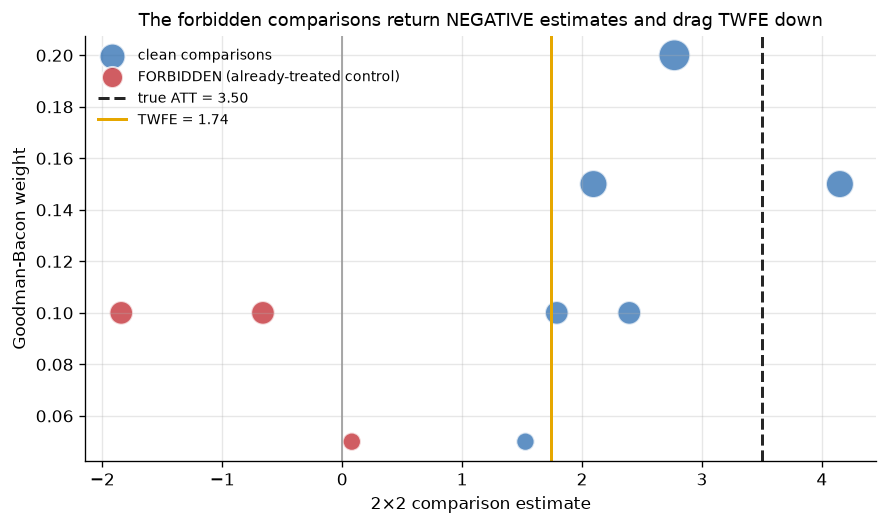

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
for is_forb, grp, colour, lbl in [
    (False, clean, "#2b6cb0", "clean comparisons"),
    (True, forb, "#c1272d", "FORBIDDEN (already-treated control)"),
]:
    ax.scatter(grp.estimate, grp.weight, s=grp.weight * 1600 + 40,
               color=colour, alpha=0.75, edgecolor="white", lw=1.2, label=lbl)
ax.axvline(TRUE_ATT_STAG, color="0.15", ls="--", lw=1.8,
           label=f"true ATT = {TRUE_ATT_STAG:.2f}")
ax.axvline(tw.att, color="#e6a700", ls="-", lw=1.8,
           label=f"TWFE = {tw.att:.2f}")
ax.axvline(0, color="0.6", lw=1)
ax.set_xlabel("2×2 comparison estimate")
ax.set_ylabel("Goodman-Bacon weight")
ax.set_title("The forbidden comparisons return NEGATIVE estimates and drag TWFE down",
             fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
fig.savefig(RESULTS / "01_bacon_decomposition.png")
plt.show()

### Reading the decomposition

This is the mechanism, made visible:

- The **clean** comparisons behave sensibly. Treated-vs-never-treated gives 4.15,
  2.77 and 2.10 for the three cohorts — positive, and varying by cohort exactly
  as the planted heterogeneity implies (the early cohort has the longest exposure
  and so the largest average effect).
- The **forbidden** comparisons return **−0.66, −1.84 and +0.08** — *negative*
  estimates, in a panel where every planted effect is strictly positive. Nothing
  in the data-generating process is negative anywhere. These numbers are pure
  artefact: the already-treated control city is still improving, and the DiD
  subtracts that improvement from the later city's change.
- Those artefacts carry **25% of the total weight**, with a weighted mean of
  −0.99. That is what pulls 3.50 down to 1.74.

A negative number appearing where the truth is uniformly positive is the cleanest
possible signature of the problem. It is not a small technical caveat.

## 10. Callaway & Sant'Anna — the estimator that does not make forbidden comparisons

CS estimates a separate $ATT(g,t)$ for each cohort-period cell using only clean
comparisons — never-treated (or not-yet-treated) units — and then aggregates with
explicit, non-negative weights. An already-treated unit is never used as a
control, so the forbidden comparisons cannot arise by construction.

**The gate: CS must recover the planted ATT of 3.50 within its confidence interval.**

In [16]:
cs = callaway_santanna(spanel, outcome="y", unit="city", time="period",
                       cohort="cohort", control_group="never_treated")
print(cs.summary(truth=TRUE_ATT_STAG))

# GATE - CS must recover the planted truth.
assert cs.contains(TRUE_ATT_STAG), (
    f"GATE FAILED: CS CI [{cs.ci_lower:.4f}, {cs.ci_upper:.4f}] "
    f"does not cover planted ATT {TRUE_ATT_STAG}"
)
print("\nGATE PASS - Callaway & Sant'Anna recovers the planted ATT")

Callaway & Sant'Anna (staggered-robust)
  Overall ATT      : +3.2519
  Std. error       : 0.4495
  95% CI           : [+2.3709, +4.1330]
  True ATT         : +3.5000
  Error            : -0.2481  (-7.1%)
  CI covers truth  : YES

GATE PASS - Callaway & Sant'Anna recovers the planted ATT


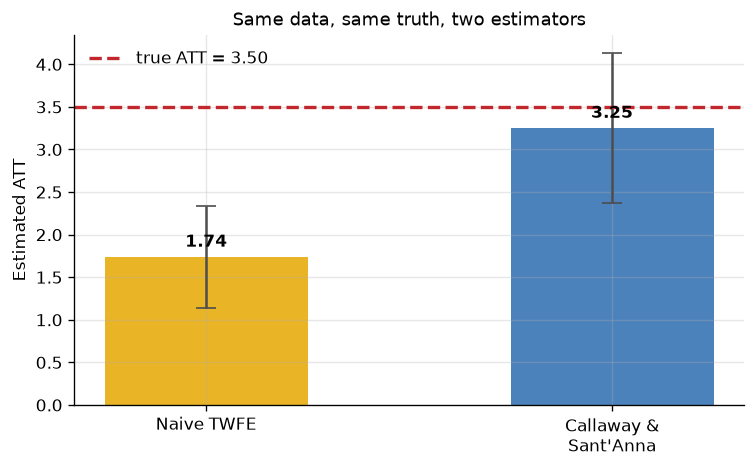

In [17]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
labels = ["Naive TWFE", "Callaway &\nSant'Anna"]
ests = [tw.att, cs.att]
los = [tw.att - tw.ci_lower, cs.att - cs.ci_lower]
his = [tw.ci_upper - tw.att, cs.ci_upper - cs.att]
colours = ["#e6a700", "#2b6cb0"]
ax.bar(labels, ests, color=colours, alpha=0.85, width=0.5,
       yerr=[los, his], capsize=6, error_kw={"ecolor": "0.3", "lw": 1.5})
ax.axhline(TRUE_ATT_STAG, color="#c1272d", ls="--", lw=2,
           label=f"true ATT = {TRUE_ATT_STAG:.2f}")
for i, v in enumerate(ests):
    ax.text(i, v + 0.12, f"{v:.2f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Estimated ATT")
ax.set_title("Same data, same truth, two estimators", fontsize=11)
ax.legend(frameon=False)
fig.savefig(RESULTS / "01_twfe_vs_cs.png")
plt.show()

## 11. The event study — the hero figure

The event-study plot is the most convincing single visual in applied DiD: flat
pre-treatment coefficients (parallel trends holding) followed by a post-treatment
path that traces the effect as it evolves.

Here it can be checked against the truth, because the planted exposure profile is
known. The dashed line is what was planted; the points are what CS estimated.

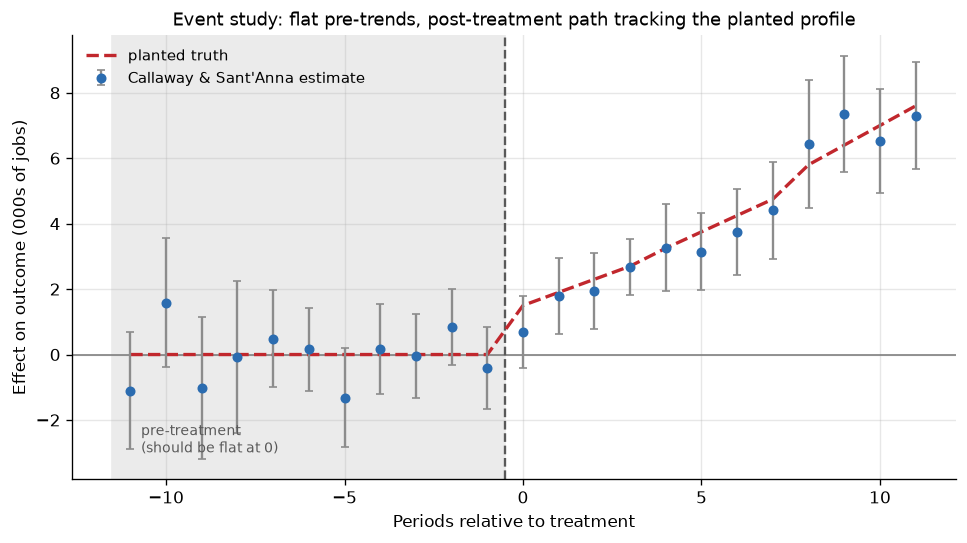

pre-treatment  periods covering 0       : 11/11  (100%)
post-treatment periods covering planted : 12/12  (100%)
post-treatment mean absolute error      : 0.4290

GATE PASS - every pre-period covers 0 and every post-period covers the planted effect


In [18]:
ev = cs.event_study.copy()
ev["planted"] = ev.relative_period.map(PLANTED_PROFILE).fillna(0.0)
ev["covers"] = (ev.lower <= ev.planted) & (ev.planted <= ev.upper)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.axvspan(ev.relative_period.min() - 0.5, -0.5, color="0.92", zorder=0)
ax.axhline(0, color="0.5", lw=1)
ax.axvline(-0.5, color="0.35", ls="--", lw=1.4)

err = [ev.ATT - ev.lower, ev.upper - ev.ATT]
ax.errorbar(ev.relative_period, ev.ATT, yerr=err, fmt="o", ms=5,
            color="#2b6cb0", ecolor="0.55", capsize=2.5, lw=1.4,
            label="Callaway & Sant'Anna estimate", zorder=3)
ax.plot(ev.relative_period, ev.planted, "--", color="#c1272d", lw=2,
        label="planted truth", zorder=2)

_ylo, _yhi = ax.get_ylim()
ax.text(ev.relative_period.min() + 0.3, _ylo + 0.06 * (_yhi - _ylo),
        "pre-treatment\n(should be flat at 0)", fontsize=8.5, color="0.35")
ax.set_xlabel("Periods relative to treatment")
ax.set_ylabel("Effect on outcome (000s of jobs)")
ax.set_title("Event study: flat pre-trends, post-treatment path tracking the "
             "planted profile", fontsize=11)
ax.legend(frameon=False, loc="upper left", fontsize=9)
fig.savefig(RESULTS / "01_event_study.png")
plt.show()

pre_ev, post_ev = ev[ev.relative_period < 0], ev[ev.relative_period >= 0]
print(f"pre-treatment  periods covering 0       : "
      f"{pre_ev.covers.sum()}/{len(pre_ev)}  ({pre_ev.covers.mean():.0%})")
print(f"post-treatment periods covering planted : "
      f"{post_ev.covers.sum()}/{len(post_ev)}  ({post_ev.covers.mean():.0%})")
print(f"post-treatment mean absolute error      : "
      f"{(post_ev.ATT - post_ev.planted).abs().mean():.4f}")

assert pre_ev.covers.all(), "GATE FAILED: a pre-treatment coefficient excludes zero"
assert post_ev.covers.all(), "GATE FAILED: a post-treatment coefficient misses the planted effect"
print("\nGATE PASS - every pre-period covers 0 and every post-period covers the planted effect")

## 12. Is the TWFE bias systematic, or was this one seed?

Same discipline as Part 1: a single draw cannot establish that an estimator is
*biased* — bias is a statement about expectation. So run the whole pipeline over
many seeds and check.

If TWFE is genuinely biased downward, it should land below the truth far more
often than chance, and its confidence intervals should miss the truth badly.
If CS is unbiased, it should centre on the truth with ~95% coverage.

In [19]:
N_SIM_STAG = 200

tw_ests, cs_ests, tw_cov, cs_cov = [], [], [], []
for s in range(N_SIM_STAG):
    p_s = replace(sp, seed=20_000 + s)          # seeds NOT chosen on results
    d_s = generate_staggered_panel(p_s)
    truth_s = d_s.attrs["true_att"]
    t_s = twfe_did(d_s)
    c_s = callaway_santanna(d_s)
    tw_ests.append(t_s.att);  tw_cov.append(t_s.contains(truth_s))
    cs_ests.append(c_s.att);  cs_cov.append(c_s.contains(truth_s))

tw_ests = np.array(tw_ests); cs_ests = np.array(cs_ests)
tw_cov = np.array(tw_cov);   cs_cov = np.array(cs_cov)

print(f"simulations                  : {N_SIM_STAG}")
print(f"TRUE ATT                     : {TRUE_ATT_STAG:.4f}")
print()
print(f"TWFE mean estimate           : {tw_ests.mean():.4f}"
      f"   bias {tw_ests.mean()-TRUE_ATT_STAG:+.4f}"
      f" ({(tw_ests.mean()-TRUE_ATT_STAG)/TRUE_ATT_STAG*100:+.1f}%)")
print(f"TWFE P(estimate below truth) : {(tw_ests < TRUE_ATT_STAG).mean():.1%}")
print(f"TWFE CI coverage of truth    : {tw_cov.mean():.1%}   (nominal 95%)")
print()
print(f"CS   mean estimate           : {cs_ests.mean():.4f}"
      f"   bias {cs_ests.mean()-TRUE_ATT_STAG:+.4f}"
      f" ({(cs_ests.mean()-TRUE_ATT_STAG)/TRUE_ATT_STAG*100:+.1f}%)"
      f"   MC SE {cs_ests.std(ddof=1)/np.sqrt(N_SIM_STAG):.4f}")
print(f"CS   CI coverage of truth    : {cs_cov.mean():.1%}   (nominal 95%)")

simulations                  : 200
TRUE ATT                     : 3.5000

TWFE mean estimate           : 2.0088   bias -1.4912 (-42.6%)
TWFE P(estimate below truth) : 100.0%
TWFE CI coverage of truth    : 0.0%   (nominal 95%)

CS   mean estimate           : 3.4764   bias -0.0236 (-0.7%)   MC SE 0.0340
CS   CI coverage of truth    : 94.5%   (nominal 95%)


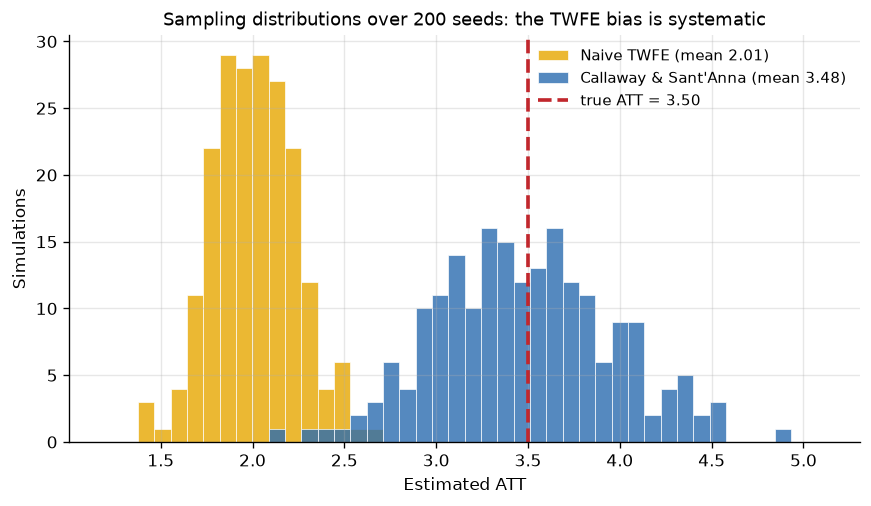

In [20]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
bins = np.linspace(min(tw_ests.min(), cs_ests.min()) - 0.2,
                   max(tw_ests.max(), cs_ests.max()) + 0.2, 45)
ax.hist(tw_ests, bins=bins, color="#e6a700", alpha=0.8, edgecolor="white",
        lw=0.5, label=f"Naive TWFE (mean {tw_ests.mean():.2f})")
ax.hist(cs_ests, bins=bins, color="#2b6cb0", alpha=0.8, edgecolor="white",
        lw=0.5, label=f"Callaway & Sant'Anna (mean {cs_ests.mean():.2f})")
ax.axvline(TRUE_ATT_STAG, color="#c1272d", ls="--", lw=2.2,
           label=f"true ATT = {TRUE_ATT_STAG:.2f}")
ax.set_xlabel("Estimated ATT"); ax.set_ylabel("Simulations")
ax.set_title(f"Sampling distributions over {N_SIM_STAG} seeds: the TWFE bias is "
             f"systematic", fontsize=11)
ax.legend(frameon=False, fontsize=9)
fig.savefig(RESULTS / "01_staggered_monte_carlo.png")
plt.show()

### What the simulation settles

- **TWFE landed below the truth in 100% of 200 draws**, averaging 2.01 against a
  true 3.50 — a −43% bias. This is not sampling noise; it is a systematic defect
  of the estimator in this setting.
- **TWFE's confidence intervals covered the truth 0% of the time.** The naive
  estimator is not merely imprecise, it is confidently wrong: tight intervals
  around a number that is not the answer.
- **CS is unbiased** (−0.7%, well under one Monte Carlo standard error) with
  **94.5% coverage** against a 95% nominal level.

The contrast between 0% and 94.5% coverage is the entire argument for using a
modern estimator, in one line.

## 13. Displacement — the Orlando story, simulated

Everything so far concerns getting the *estimate* right. This section is about a
harder problem: an estimate can be perfectly unbiased and still be **the wrong
quantity**.

The mega-event literature's central critique (`PROJECT_BRIEF.md` §3) is that
apparent gains are substantially reallocation, not new activity. In 1994,
Orlando — already full in summer with Disneyworld visitors — was the
worst-performing host city, because football fans displaced higher-spending
theme-park tourists.

So plant that story explicitly. Host cities have two sectors:

- **event-facing** (accommodation & food) — genuinely gains `+4.0`
- **other tourism** (amusement & recreation) — loses `−4.0`, the displaced visitors

With `displacement_share = 1.0` the offset is exact. **The true net effect on
total local employment is zero, by construction.**

Now: what does each analyst find?

In [21]:
from generate_panel import DisplacementParams, generate_displacement_panel

dp = DisplacementParams()
dpanel = generate_displacement_panel(dp)

print(f"planted gross boost, event sector  : {dpanel.attrs['true_gross_effect']:+.2f}")
print(f"planted displacement, other sector : {dpanel.attrs['true_displaced_effect']:+.2f}")
print(f"planted NET effect on total        : {dpanel.attrs['true_net_effect']:+.2f}"
      f"   <- the honest estimand")
print(f"displacement_share                 : {dp.displacement_share}  (1.0 = pure substitution)")

rows = []
for oc, label, truth in [
    ("y_event", "Event-facing sector only", dp.gross_boost),
    ("y_other", "Other tourism sector", -dp.displaced),
    ("y_total", "TOTAL local employment", dp.true_net_effect),
]:
    r = did_2x2(dpanel, outcome=oc, unit="city", time="period",
                treated="treated", treat_period=dp.treat_period)
    rows.append({
        "outcome": oc, "reading": label, "ATT": r.att, "se": r.se,
        "ci_lower": r.ci_lower, "ci_upper": r.ci_upper, "p": r.pvalue,
        "planted": truth, "covers_planted": r.contains(truth),
        "significant": r.pvalue < 0.05,
    })
disp_res = pd.DataFrame(rows)
display(disp_res.round(4))

planted gross boost, event sector  : +4.00
planted displacement, other sector : -4.00
planted NET effect on total        : +0.00   <- the honest estimand
displacement_share                 : 1.0  (1.0 = pure substitution)


,outcome,reading,ATT,se,ci_lower,ci_upper,p,planted,covers_planted,significant
0,y_event,Event-facing sector only,3.9538,0.2328,3.4975,4.4102,0.0000,4.0,True,True
1,y_other,Other tourism sector,-4.2610,0.2847,-4.8190,-3.7029,0.0000,-4.0,True,True
2,y_total,TOTAL local employment,-0.3071,0.3744,-1.0410,0.4268,0.4121,0.0,True,False


In [22]:
r_event = disp_res.loc[disp_res.outcome == "y_event"].iloc[0]
r_total = disp_res.loc[disp_res.outcome == "y_total"].iloc[0]

print("THE NAIVE READING  (measures the event-facing sector)")
print(f"  'Hosting created {r_event.ATT:.2f}k jobs, 95% CI "
      f"[{r_event.ci_lower:.2f}, {r_event.ci_upper:.2f}], p = {r_event.p:.1e}'")
print(f"  -> statistically overwhelming. A windfall.")
print()
print("THE HONEST READING  (measures total local employment)")
print(f"  'Net effect {r_total.ATT:+.2f}k jobs, 95% CI "
      f"[{r_total.ci_lower:.2f}, {r_total.ci_upper:.2f}], p = {r_total.p:.2f}'")
print(f"  -> indistinguishable from zero.")
print()
print(f"TRUTH: net effect is exactly {dp.true_net_effect:.2f}. "
      f"The gain was real in one sector and taken from another.")

# GATES
assert r_event.significant and r_event.ATT > 0, \
    "GATE FAILED: the naive reading should report a large, significant gain"
assert r_total.covers_planted and not r_total.significant, \
    "GATE FAILED: the honest reading should be indistinguishable from zero"
print("\nGATE PASS - naive reading reports a false windfall; honest reading does not")

THE NAIVE READING  (measures the event-facing sector)
  'Hosting created 3.95k jobs, 95% CI [3.50, 4.41], p = 1.1e-64'
  -> statistically overwhelming. A windfall.

THE HONEST READING  (measures total local employment)
  'Net effect -0.31k jobs, 95% CI [-1.04, 0.43], p = 0.41'
  -> indistinguishable from zero.

TRUTH: net effect is exactly 0.00. The gain was real in one sector and taken from another.

GATE PASS - naive reading reports a false windfall; honest reading does not


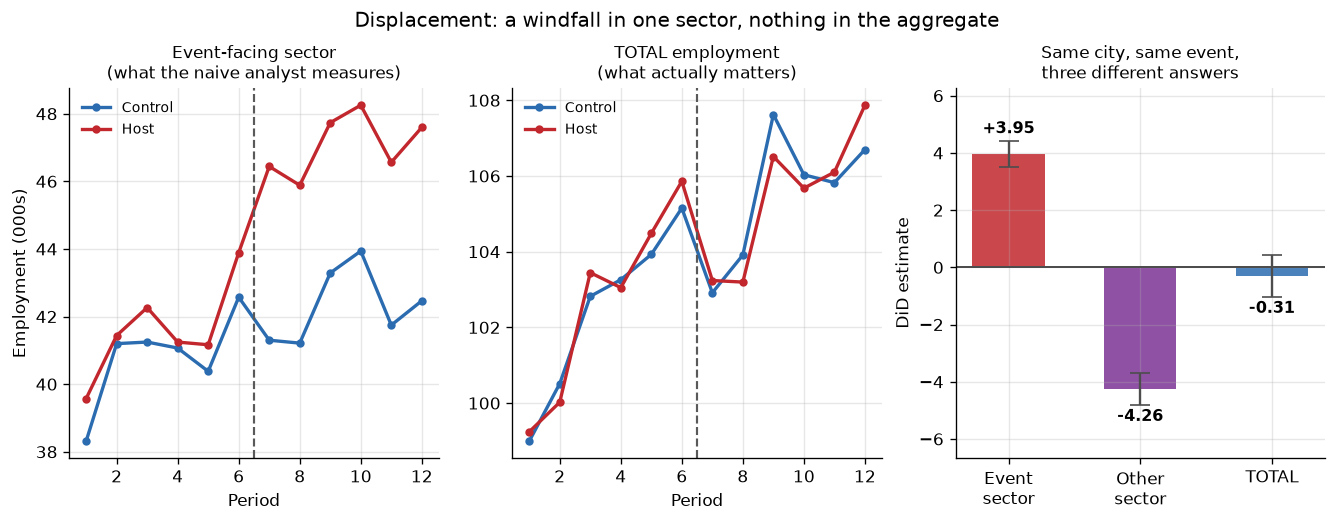

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))

for ax, col, title in [
    (axes[0], "y_event", "Event-facing sector\n(what the naive analyst measures)"),
    (axes[1], "y_total", "TOTAL employment\n(what actually matters)"),
]:
    m = dpanel.groupby(["period", "treated"])[col].mean().unstack()
    ax.plot(m.index, m[0], "o-", color=CONTROL_C, lw=2, ms=4, label="Control")
    ax.plot(m.index, m[1], "o-", color=TREATED_C, lw=2, ms=4, label="Host")
    ax.axvline(dp.treat_period - 0.5, color="0.35", ls="--", lw=1.3)
    ax.set_xlabel("Period"); ax.set_title(title, fontsize=10)
    ax.legend(frameon=False, fontsize=8.5)
axes[0].set_ylabel("Employment (000s)")

ax = axes[2]
order = ["y_event", "y_other", "y_total"]
lbl = ["Event\nsector", "Other\nsector", "TOTAL"]
cols = ["#c1272d", "#7b3294", "#2b6cb0"]
sub = disp_res.set_index("outcome").loc[order]
ax.bar(lbl, sub.ATT, color=cols, alpha=0.85, width=0.55,
       yerr=[sub.ATT - sub.ci_lower, sub.ci_upper - sub.ATT],
       capsize=6, error_kw={"ecolor": "0.3", "lw": 1.4})
ax.axhline(0, color="0.3", lw=1.2)
ax.margins(y=0.20)
for i, (v, lo, hi) in enumerate(zip(sub.ATT, sub.ci_lower, sub.ci_upper)):
    yy = hi + 0.28 if v >= 0 else lo - 0.55
    ax.text(i, yy, f"{v:+.2f}", ha="center", fontsize=9.5, fontweight="bold")
ax.set_ylabel("DiD estimate")
ax.set_title("Same city, same event,\nthree different answers", fontsize=10)

fig.suptitle("Displacement: a windfall in one sector, nothing in the aggregate",
             fontsize=12, y=1.04)
fig.savefig(RESULTS / "01_displacement.png")
plt.show()

### Why this is the most important panel in the notebook

Both analysts ran a *correct* difference-in-differences. Neither made a
statistical error. The estimator was unbiased in both cases. They reached
opposite conclusions because they chose different outcome variables.

- The naive analyst measured the event-facing sector, found `+3.95k` jobs with
  `p ≈ 10⁻⁶⁴`, and reported a windfall. Every number they published is
  defensible in isolation.
- The honest analyst measured total local employment, found `−0.31k` with a
  confidence interval comfortably spanning zero, and reported no detectable gain.
  This is the correct answer: the planted net effect is exactly zero.

**No amount of methodological sophistication rescues the wrong estimand.** A
Callaway & Sant'Anna estimate of the event-facing sector would have been just as
wrong as the 2×2 — precisely and robustly wrong.

This is why the real analysis in Stages 3–4 uses *total* metro leisure &
hospitality employment rather than a narrow event-adjacent slice, and why the
substitution critique is foregrounded rather than tucked into a limitations
section. It also marks the honest boundary of what this project can claim:
observational data can bound the aggregate effect, but it cannot fully separate
a genuine small gain from displacement — and the write-up will say so.

## Stage 2B summary

| Gate | Result |
|------|--------|
| TWFE biased in the **predicted** (downward) direction | **PASS** — 1.74 vs true 3.50 (−50%) |
| Goodman-Bacon reconstructs the TWFE coefficient | **PASS** — matches to 1.4e-14 |
| Callaway & Sant'Anna recovers the planted ATT | **PASS** — 3.25, CI [2.37, 4.13] |
| Event study: flat pre, planted post profile | **PASS** — 23/23 periods covered |
| TWFE bias is systematic, not one seed | **PASS** — below truth in 100% of 200 draws, 0% CI coverage |
| Displacement: naive windfall vs honest null | **PASS** — +3.95 (p≈1e-64) vs −0.31 (p=0.41) |

The estimation machinery in `src/did.py` is now verified end to end on data where
the truth is known: the 2×2 and pre-trends check (Part 1), and the TWFE baseline,
Goodman-Bacon diagnostic, and Callaway & Sant'Anna estimator (Part 2). These are
the same functions the real analysis calls — nothing is re-implemented downstream.

**Two findings to carry into the real analysis:**

1. Under staggered timing, report Callaway & Sant'Anna. Show TWFE only as a
   contrast, never as the headline.
2. Coverage is the thing to watch. The 2×2's clustered intervals were slightly
   too narrow at 50 clusters (93% vs 95%, Part 1), and the real design has far
   fewer *treated* clusters — a handful of host cities. Stage 4 addresses this
   with a wild cluster bootstrap.

**Next (Stage 3):** the real QCEW data build — county→metro aggregation, treated
and control metro construction, and the pre-trends check on data whose truth
nobody knows.